# Implementing GPT-2 Transformer Architecture

This notebook combines theoretical understanding with hands-on implementation of Transformer-based generative models. We will implement attention mechanisms, multi-head attention, and a GPT-2 model from scratch, followed by small-scale pretraining. The concepts and code used in this notebook draws reference from my academic pursuit in AI Masters from SUTD (Singapore University of Technology & Design)

In [4]:
import torch
from torch import nn, dtype
import matplotlib.pyplot as plt
from d2l import torch as d2l
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from config import PretrainedConfig, GPT2Config
from transformers import GPT2Model as OpenAIGPT2Model
from transformers import GPT2Tokenizer
from utils import *
from einops import rearrange
import math
import matplotlib.pyplot as plt
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device(
      "cuda" if torch.cuda.is_available()
      else "mps" if torch.backends.mps.is_available()
      else "cpu"
)
print(DEVICE)

mps


One of the core challenges in NLP is how to represent language, whose nature lies in its sequential structure. To address this, various sequence modeling architectures have been proposed. Among them, Transformers are the most representative, relying on attention mechanisms to capture dependencies across all positions in a sequence.

## Attention Mechanisms

Consider the following: denote by $\mathcal{D} = \{(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)\}$ a database of $m$ tuples of *keys* and *values*. Moreover, denote by $\mathbf{q}$ a *query*. Then we can define the *attention* over $\mathcal{D}$ as

$$
\text{Attention}(\mathbf{q}, \mathcal{D}) = \sum_{i=1}^{m} \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i
$$

where $\alpha(\mathbf{q}, \mathbf{k}_i) \in \mathcal{R}$ $(i = 1, \ldots, m)$ are scalar attention weights. This operation is commonly known as *attention pooling*. The term *attention* reflects the mechanism’s ability to focus on specific elements in the dataset, assigning higher weights $\alpha$ to the terms in $\mathcal{D}$ that are deemed more relevant or significant. Consequently, the attention mechanism produces a weighted linear combination of the values in the database, emphasizing the most important components.

A common strategy for ensuring that the weights sum up to 1 is to normalize them via

$$
\alpha(\mathbf{q}, \mathbf{k}_i) = \frac{\alpha(\mathbf{q}, \mathbf{k}_i)}{\sum_j \alpha(\mathbf{q}, \mathbf{k}_j)}.
$$

In particular, to ensure that the weights are also nonnegative, one can resort to exponentiation. This means that we can now pick any function $a(\mathbf{q}, \mathbf{k})$ and then apply the softmax operation used for multinomial models to it via

$$
\alpha(\mathbf{q}, \mathbf{k}_i) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_j \exp(a(\mathbf{q}, \mathbf{k}_j))}.
$$

Then, we need to keep the order of magnitude of the arguments in the exponential function under control. Assume that all the elements of the query $\mathbf{q} \in \mathcal{R}^d$ and the key $\mathbf{k}_i \in \mathcal{R}^d$ are independent and identically drawn random variables with zero mean and unit variance. The dot product between both vectors has zero mean and a variance of $d$. To ensure that the variance of the dot product still remains 1 regardless of vector length, we use the *scaled dot product attention* scoring function. That is, we rescale the dot product by $1/\sqrt{d}$. We thus arrive at the first commonly used attention function that is used:

$$
a(\mathbf{q}, \mathbf{k}_i) = \frac{\mathbf{q}^\top \mathbf{k}_i}{\sqrt{d}}.
$$

Note that attention weights $\alpha$ still need normalizing. We can simplify this further via the softmax operation:

$$
\alpha(\mathbf{q}, \mathbf{k}_i) = \text{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(\mathbf{q}^\top \mathbf{k}_i / \sqrt{d})}{\sum_{j=1}^m \exp(\mathbf{q}^\top \mathbf{k}_j / \sqrt{d})}.
$$

### Masked Softmax

In sequence modeling, different input sequences often have different lengths.
For example, consider the following batch of three sentences (each padded to the same maximum length):

| Study | about | Deep    | Learning  |
|-------|-------|---------|-----------|
| Start | by    | code    | `<pad>` |
| Hello | world | `<pad>` | `<pad>` |

Here, the valid lengths are **[4, 3, 2]**, and `<pad>` represents padding tokens that should not affect the computation.

To put them in the same batch and compute correctly, we usually apply a mask so that positions beyond the valid length are ignored — that is, their probabilities after softmax become zero.

We will implement function ``masked_softmax``, which performs the softmax operation but masks out elements beyond the valid lengths

In [5]:
def masked_softmax(X, valid_lens=None):  #@save
    """Perform softmax operation by masking elements on the last axis."""
    # Shape of X: (batch_size, num_queries, num_keys)
    # Shape of valid_lens: (batch_size,) or (batch_size, num_queries)
    def _sequence_mask(X, valid_lens, value=0):
        # Shape of X: (batch_size * num_queries, num_keys)
        # Shape of valid_lens: (batch_size * num_queries,)
        ### YOUR CODE HERE (10 points)
        maxlen = X.size(1) # get the max sequence length (num_keys)
        # create a mask of shape (batch_size * num_queries, num_keys) where True indicates valid positions and False indicates masked positions
        mask = torch.arange(maxlen, dtype=torch.int32, device=X.device)[None, :] < valid_lens[:, None] 
        X[~mask] = value
        return X
        ### END OF YOUR CODE

    if valid_lens is None:
        ### YOUR CODE HERE (2 points)
        # if valid_lens is None, this means no padding exists -> no masking is needed
        # directly apply softmax and return the result
        return nn.functional.softmax(X, dim=-1)
        ### END OF YOUR CODE
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        ### YOUR CODE HERE (3 points)
        # reshape X back to its original shape and apply softmax along the last axis (key dimension)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

        ### END OF YOUR CODE

In [6]:
# sanity check
# Assume num_queries = 1
masked_softmax(torch.rand(3, 1, 4), torch.tensor([4, 2, 3]))
# masked_softmax(torch.rand(3, 1, 4))

tensor([[[0.2984, 0.2351, 0.2259, 0.2407]],

        [[0.5837, 0.4163, 0.0000, 0.0000]],

        [[0.3976, 0.1879, 0.4146, 0.0000]]])

### Implementing DotProduct Attention

In [7]:
class DotProductAttention(nn.Module):  #@save
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # Shape of queries: (batch_size, n, d)
        # Shape of keys: (batch_size, m, d)
        # Shape of values: (batch_size, m, v)
        # Shape of valid_lens: (batch_size,) or (batch_size, num_queries)

        ### YOUR CODE HERE
        # step 1: calculate the dot product attention scores Q.K^T / sqrt (d) where d is the dimension of the queries/keys
        d = queries.shape[-1]
        attention_scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)

        # step 2: apply masked softmax to the attention scores to get the attention weights
        attention_weights = masked_softmax(attention_scores, valid_lens)

        ### END OF YOUR CODE
        return torch.bmm(self.dropout(attention_weights), values), attention_weights

In [8]:
# sanity check
queries = torch.normal(0, 1, (3, 10, 4))
keys = torch.normal(0, 1, (3, 12, 4))
values = torch.normal(0, 1, (3, 12, 4))
valid_lens = torch.tensor([7, 9, 12])

attention = DotProductAttention(dropout=0.5)
attention.eval()
results, attention_weights = attention(queries, keys, values, valid_lens)
d2l.check_shape(results, (3, 10, 4))
print("Pass!")

Pass!


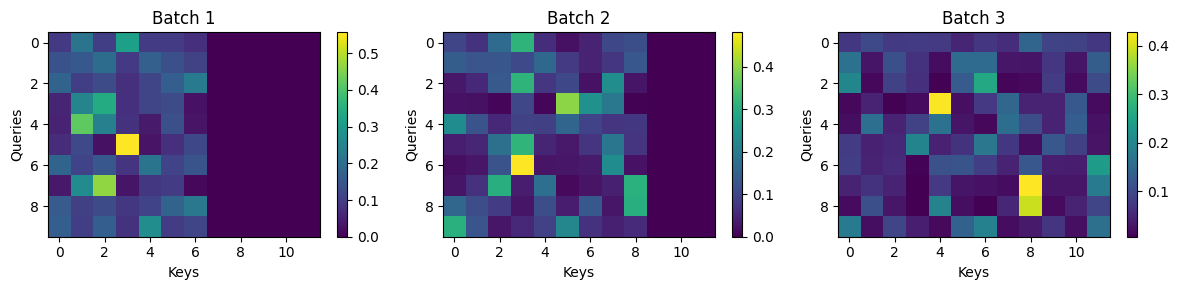

In [9]:
b, q, k = attention_weights.shape
fig, axes = plt.subplots(1, b, figsize=(4*b, 3))
if b == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    mat = attention_weights[i].detach().cpu().numpy()   # shape (num_queries, num_keys)
    im = ax.imshow(mat, cmap='viridis', aspect='auto', interpolation='nearest')
    ax.set_xlabel('Keys')
    ax.set_ylabel('Queries')
    ax.set_title(f'Batch {i+1}')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Multihead Attention
Rather than relying on a single attention pooling operation, the queries, keys, and values can be transformed through $h$ independently learned linear projections. These $h$ projected queries, keys, and values are then processed in parallel through attention pooling. Afterward, the $h$ resulting attention outputs, known as ``heads``, are concatenated and passed through another learned linear projection to generate the final output. This architecture, referred to as ``multi-head attention``, allows each attention head to focus on different parts of the input, enabling the model to capture a wider range of information.

![ma](Multihead_attention.png)

Given a query $\mathbf{q} \in \mathcal{R}^{d_q}$, a key $\mathbf{k} \in \mathcal{R}^{d_k}$, and a value $\mathbf{v} \in \mathcal{R}^{d_v}$, each attention head $\mathbf{h}_i$ $(i = 1, \ldots, h)$ is computed as:

\begin{equation}
\mathbf{h}_i = f(\mathbf{W}_i^{(q)} \mathbf{q}, \mathbf{W}_i^{(k)} \mathbf{k}, \mathbf{W}_i^{(v)} \mathbf{v}) \in \mathcal{R}^{p_v},
\end{equation}

where $\mathbf{W}_i^{(q)} \in \mathcal{R}^{p_q \times d_q}$, $\mathbf{W}_i^{(k)} \in \mathcal{R}^{p_k \times d_k}$, and $\mathbf{W}_i^{(v)} \in \mathcal{R}^{p_v \times d_v}$ are learnable parameters and $f$ is attention pooling. The multi-head attention output is another linear transformation via learnable parameters $\mathbf{W}_o \in \mathcal{R}^{p_o \times hp_v}$ of the concatenation of $h$ heads:

\begin{equation}
\mathbf{W}_o 
\begin{bmatrix}
\mathbf{h}_1 \\
\vdots \\
\mathbf{h}_h
\end{bmatrix}
\in \mathcal{R}^{p_o}. 
\end{equation}

Based on this design, each head may attend to different parts of the input. More sophisticated functions than the simple weighted average can be expressed.

### Benefits of Multi-head vs Single-head Attention

1. **Multi-head attention captures multiple relationship types simultaneously between tokens** <br>
Multi-head attention projects queries, keys, and values into multiple independent subspaces, enabling the model to simultaneously capture different types of relationships between tokens within a single layer — for example, article-noun dependencies, subject-verb associations, and positional patterns. A single head can only learn one blended attention pattern, forcing it to average these diverse signals and lose distinct information. After concatenation, the output projection (W_o) and feed-forward layers combine insights across heads, detecting compositional patterns that no single head could capture alone.

2. **Same computation cost** <br>
Multi-head splits the hidden dimension into h heads of d_k dims, which doesn't increase the total parameters or compute. The Q @ K^T cost is the same — just distributed across heads

3. **More robust through redundancy** <br>
If a single head learns a bad attention pattern, the entire layer's output suffers. With multiple heads, one bad head is averaged out by the others — the model degrades gracefully.

In [10]:
class MultiHeadAttention(nn.Module):  #@save
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of queries, keys, or values:
        # (batch_size, no. of queries or key-value pairs, num_hiddens)
        # Shape of valid_lens: (batch_size,) or (batch_size, num_queries)
        
        ### YOUR CODE HERE
        # step 1: apply linear transformations to queries, keys, and values using W_q, W_k, and W_v respectively
        # and then reshape and transpose them to prepare for multi-head attention computation using the transpose_qkv function
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        # step 2: repeat valid_lens for each head to match the shape of the attention scores
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, self.num_heads)
        
        # step 3: run attention on all heads at once
        output = self.attention(queries, keys, values, valid_lens)

        # step 4: merge heads back
        output_concat = self.transpose_output(output)

        ### END OF YOUR CODE
        return self.W_o(output_concat)
    
    def transpose_qkv(self, X):
        """Transposition for parallel computation of multiple attention heads."""
        # Shape of X: (batch_size, no. of queries or key-value pairs,
        # num_hiddens)

        ### YOUR CODE HERE
        # step 1: reshape X (batch_size, seq_len [queries or key-value pairs], num_hiddens) to (batch_size, seq_len, num_heads, num_hiddens // num_heads)
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, X.shape[2] // self.num_heads)

        # step 2: rearrange the dimensions to (batch_size, num_heads, seq_len, num_hiddens // num_heads) to merge the num_heads dimension with the batch_size dimension for efficient computation of attention
        X = X.permute(0, 2, 1, 3)

        # step 3: reshape X to (batch_size * num_heads, seq_len, num_hiddens // num_heads) to combine the batch_size and num_heads dimensions for efficient computation of attention
        return X.reshape(-1, X.shape[2], X.shape[3])  

        # Shape of output: (batch_size*num_heads, no. of queries or key-value pairs, 
        # num_hiddens / num_heads)
        ### END OF YOUR CODE

    def transpose_output(self, X):
        """Reverse the operation of transpose_qkv."""
        # Shape of X: (batch_size * num_heads, num_queries,
        # num_hiddens / num_heads)
        
        ### YOUR CODE HERE
        # (batch*heads, seq, head_dim) → (batch, heads, seq, head_dim)  e.g. (10,4,20) → (2,5,4,20)                                                                     
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])                                                                                                       
        # (batch, heads, seq, head_dim) → (batch, seq, heads, head_dim)  e.g. (2,5,4,20) → (2,4,5,20)
        X = X.permute(0, 2, 1, 3)                                                                                                                                       
        # (batch, seq, heads, head_dim) → (batch, seq, num_hiddens)  e.g. (2,4,5,20) → (2,4,100)          
        return X.reshape(X.shape[0], X.shape[1], -1)  

        # Shape of output: (batch_size, seq_len, num_hiddens)
        ### END OF YOUR CODE

In [11]:
# sanity check
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.5)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 6])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
d2l.check_shape(attention(X, Y, Y, valid_lens),
                (batch_size, num_queries, num_hiddens))
print("Pass!")

Pass!


## GPT-2 Pretraining

The following experiment is a small-scale pretraining experiment on a transformer-based GPT-2 model.

### Implementing CausalSelfAttention

In [12]:
class CausalSelfAttention(nn.Module):
  def __init__(self, config):
    super().__init__()

    self.num_attention_heads = config.num_attention_heads
    self.attention_head_size = int(config.hidden_size / config.num_attention_heads)
    self.all_head_size = self.num_attention_heads * self.attention_head_size

    # Initialize the linear transformation layers for key, value, query.
    self.query = nn.Linear(config.hidden_size, self.all_head_size)
    self.key = nn.Linear(config.hidden_size, self.all_head_size)
    self.value = nn.Linear(config.hidden_size, self.all_head_size)
    # This dropout is applied to normalized attention scores following the original
    # implementation of transformer. Although it is a bit unusual, we empirically
    # observe that it yields better performance.
    self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

  def transform(self, x, linear_layer):
    # The corresponding linear_layer of k, v, q are used to project the hidden_state (x).
    proj = linear_layer(x)
    # Next, we need to produce multiple heads for the proj. This is done by spliting the
    # hidden state to self.num_attention_heads, each of size self.attention_head_size.
    proj = rearrange(proj, 'b t (h d) -> b t h d', h=self.num_attention_heads)
    # By proper transpose, we have proj of size [bs, num_attention_heads, seq_len, attention_head_size].
    proj = rearrange(proj, 'b t h d -> b h t d')
    return proj

  def attention(self, key, query, value, attention_mask):
    """
    TODO: Compute scaled dot-product attention for GPT-2.

    Implementation hints:
    1. Compute raw attention scores using QK^T, and scale them by sqrt(d_k).
    2. Apply a causal mask (lower-triangular) to prevent attending to future tokens.
    3. Optionally add the external attention_mask (e.g., padding positions).
    4. Normalize the scores with softmax to obtain attention probabilities.
    5. Apply dropout on the probabilities.
    6. Use them to weight the values (V) and obtain the context vectors.
    7. Finally, merge all attention heads back into a single hidden representation.
    """
    ### YOUR CODE HERE
    # step 1- get the dimension of each head to scale the attention scores
    d_k = key.shape[-1]
    # step 2- calculate the raw attention scores using QK^T and scale them by sqrt(d_k)
    attention_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    # step 3- create a causal mask (lower triangle) to prevent attending to future tokens (1 = can see, 0 = future, blocked) 
    seq_len = query.shape[-2]
    causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=query.device)).unsqueeze(0).unsqueeze(0)
    # step 4 - apply the causal mask to the attention scores by setting masked positions to a very large negative value (e.g., -inf) so that their softmax becomes zero
    attention_scores = attention_scores.masked_fill(causal_mask == 0, float('-inf'))
    # step 5 - add external attention mask for padding (if provided)
    if attention_mask is not None:
        attention_scores = attention_scores + attention_mask

    # step 6 - apply softmax to convert scores to probabilities (dim=-1 = across keys)
    attention_probs = nn.functional.softmax(attention_scores, dim=-1)

    # step 7 - apply dropout to attention probabilities
    attention_probs = self.dropout(attention_probs)

    # step 8 - weight the values (V) by the attention probabilities to get the context vectors
    # (bs, heads, seq, seq) @ (bs, heads, seq, head_dim) → (bs, heads, seq, head_dim)
    context = torch.matmul(attention_probs, value)

    # step 9 - merge the multiple attention heads back to a single hidden representation (one vector per token)
    # (bs, heads, seq, head_dim) → (bs, seq, heads * head_dim) = (bs, seq, hidden_size)
    context = rearrange(context, 'b h t d -> b t (h d)')

    return context


  def forward(self, hidden_states, attention_mask):
    """
    hidden_states: [bs, seq_len, hidden_state]
    attention_mask: [bs, 1, 1, seq_len]
    output: [bs, seq_len, hidden_state]
    """
    # First, we have to generate the key, value, query for each token for multi-head attention
    # using self.transform (more details inside the function).
    # Size of *_layer is [bs, num_attention_heads, seq_len, attention_head_size].
    key_layer = self.transform(hidden_states, self.key)
    value_layer = self.transform(hidden_states, self.value)
    query_layer = self.transform(hidden_states, self.query)
    
    # Calculate the multi-head attention using the self.attention function.
    attn_value = self.attention(key_layer, query_layer, value_layer, attention_mask)
    return attn_value

In [13]:
class GPT2Layer(nn.Module):
  def __init__(self, config):
    super().__init__()
    # Multi-head attention.
    self.self_attention = CausalSelfAttention(config)
    # Add-norm for multi-head attention.
    self.attention_dense = nn.Linear(config.hidden_size, config.hidden_size)
    self.attention_layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
    self.attention_dropout = nn.Dropout(config.hidden_dropout_prob)
    # Feed forward.
    self.interm_dense = nn.Linear(config.hidden_size, config.intermediate_size)
    self.interm_af = F.gelu
    # Add-norm for feed forward.
    self.out_dense = nn.Linear(config.intermediate_size, config.hidden_size)
    self.out_layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
    self.out_dropout = nn.Dropout(config.hidden_dropout_prob)

  def add(self, input, output, dense_layer, dropout):
    output = dense_layer(output)
    output = dropout(output)
    return input + output


  def forward(self, hidden_states, attention_mask):
    normed_hidden = self.attention_layer_norm(hidden_states)
    attn_output = self.self_attention(normed_hidden, attention_mask)
    hidden_states = self.add(hidden_states, attn_output, self.attention_dense, self.attention_dropout)

    normed_hidden = self.out_layer_norm(hidden_states)
    ff_output = self.interm_af(self.interm_dense(normed_hidden))
    hidden_states = self.add(hidden_states, ff_output, self.out_dense, self.out_dropout)

    return hidden_states

In [14]:
class GPTPreTrainedModel(nn.Module):

  def __init__(self, config: PretrainedConfig, *inputs, **kwargs):
    super().__init__()
    self.config = config
    self.name_or_path = config.name_or_path

  def init_weights(self):
    # Initialize weights
    self.apply(self._init_weights)

  def _init_weights(self, module):
    """ Initialize the weights """
    if isinstance(module, (nn.Linear, nn.Embedding)):
      # Slightly different from the TF version which uses truncated_normal for initialization
      # cf https://github.com/pytorch/pytorch/pull/5617
      module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
    elif isinstance(module, nn.LayerNorm):
      module.bias.data.zero_()
      module.weight.data.fill_(1.0)
    if isinstance(module, nn.Linear) and module.bias is not None:
      module.bias.data.zero_()

  @property
  def dtype(self) -> dtype:
    return get_parameter_dtype(self)

In [15]:
class GPT2Model(GPTPreTrainedModel):
  """
  The GPT model returns the final embeddings for each token in a sentence.

  The model consists of:
  1. Embedding layers (used in self.embed).
  2. A stack of n GPT layers (used in self.encode).
  3. A linear transformation layer for the [CLS] token (used in self.forward, as given).
  """

  def __init__(self, config):
    super().__init__(config)
    self.config = config

    # Embedding layers.
    self.word_embedding = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_token_id)
    self.pos_embedding = nn.Embedding(config.max_position_embeddings, config.hidden_size)
    self.embed_dropout = nn.Dropout(config.hidden_dropout_prob)

    # Register position_ids (1, len position emb) to buffer because it is a constant.
    position_ids = torch.arange(config.max_position_embeddings).unsqueeze(0)
    self.register_buffer('position_ids', position_ids)

    # GPT-2 layers.
    self.gpt_layers = nn.ModuleList([GPT2Layer(config) for _ in range(config.num_hidden_layers)])

    # [CLS] token transformations.
    self.pooler_dense = nn.Linear(config.hidden_size, config.hidden_size)
    self.pooler_af = nn.Tanh()

    # Final layer norm.
    self.final_layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)

    self.init_weights()

  def embed(self, input_ids):
    input_shape = input_ids.size()
    seq_length = input_shape[1]

    # Token embeddings
    inputs_embeds = self.word_embedding(input_ids)

    # Position IDs [1, seq_len]
    pos_ids = self.position_ids[:, :seq_length]

    # Position embeddings
    pos_embeds = self.pos_embedding(pos_ids)

    # Add token + position embeddings
    hidden_states = inputs_embeds + pos_embeds

    # Apply dropout
    hidden_states = self.embed_dropout(hidden_states)

    return hidden_states

  def encode(self, hidden_states, attention_mask):
    """
    hidden_states: the output from the embedding layer [batch_size, seq_len, hidden_size]
    attention_mask: [batch_size, seq_len]
    """
    # Get the extended attention mask for self-attention.
    # Returns extended_attention_mask of size [batch_size, 1, 1, seq_len].
    # Distinguishes between non-padding tokens (with a value of 0) and padding tokens
    # (with a value of a large negative number).
    extended_attention_mask: torch.Tensor = get_extended_attention_mask(attention_mask, self.dtype)

    # Pass the hidden states through the encoder layers.
    for i, layer_module in enumerate(self.gpt_layers):
      # Feed the encoding from the last bert_layer to the next.
      hidden_states = layer_module(hidden_states, extended_attention_mask)

    return hidden_states

  def forward(self, input_ids, attention_mask):
    """
    input_ids: [batch_size, seq_len], seq_len is the max length of the batch
    attention_mask: same size as input_ids, 1 represents non-padding tokens, 0 represents padding tokens
    """
    # Get the embedding for each input token.
    embedding_output = self.embed(input_ids=input_ids)

    # Feed to a transformer (a stack of GPTLayers).
    sequence_output = self.encode(embedding_output, attention_mask=attention_mask)
    sequence_output = self.final_layer_norm(sequence_output)

    # Get the hidden state of the final token.
    last_non_pad_idx = attention_mask.sum(dim=1) - 1  # Subtract 1 to get last index
    last_token = sequence_output[torch.arange(sequence_output.shape[0]), last_non_pad_idx]

    return {'last_hidden_state': sequence_output, 'last_token': last_token}

  def hidden_state_to_token(self, hidden_state):
    logits = torch.matmul(hidden_state, self.word_embedding.weight.T)
    return logits

  @classmethod
  def from_pretrained(cls, model='gpt2', d=768, l=12, num_heads=12):
    gpt_model = OpenAIGPT2Model.from_pretrained(model).eval()
    our_model = GPT2Model(GPT2Config(hidden_size=d, num_hidden_layers=l,num_attention_heads=num_heads,
                                     intermediate_size=d*3)).eval()

    # Load word and positional embeddings.
    our_model.word_embedding.load_state_dict(gpt_model.wte.state_dict())
    our_model.pos_embedding.load_state_dict(gpt_model.wpe.state_dict())

    for i in range(l):
      l = our_model.gpt_layers[i]
      # Remap the Q,K,V weights from a conv1d to 3 linear projections
      l.self_attention.query.weight.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.weight'][:, :d].T
      l.self_attention.query.bias.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.bias'][:d]
      l.self_attention.key.weight.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.weight'][:, d:d*2].T
      l.self_attention.key.bias.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.bias'][d:d*2]
      l.self_attention.value.weight.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.weight'][:, d*2:].T
      l.self_attention.value.bias.data = gpt_model.state_dict()[f'h.{i}.attn.c_attn.bias'][d*2:]

      # Remap final dense layer in MHA.
      l.attention_dense.weight.data = gpt_model.state_dict()[f'h.{i}.attn.c_proj.weight'].T
      l.attention_dense.bias.data = gpt_model.state_dict()[f'h.{i}.attn.c_proj.bias']

      # Remap attention layer norm.
      l.attention_layer_norm.weight.data = gpt_model.state_dict()[f'h.{i}.ln_1.weight']
      l.attention_layer_norm.bias.data = gpt_model.state_dict()[f'h.{i}.ln_1.bias']

      # Remap post-attention MLP layers.
      l.interm_dense.weight.data = gpt_model.state_dict()[f'h.{i}.mlp.c_fc.weight'].T
      l.interm_dense.bias.data = gpt_model.state_dict()[f'h.{i}.mlp.c_fc.bias']
      l.out_dense.weight.data = gpt_model.state_dict()[f'h.{i}.mlp.c_proj.weight'].T
      l.out_dense.bias.data = gpt_model.state_dict()[f'h.{i}.mlp.c_proj.bias']

      # Remap second layer norm weights.
      l.out_layer_norm.weight.data = gpt_model.state_dict()[f'h.{i}.ln_2.weight']
      l.out_layer_norm.bias.data = gpt_model.state_dict()[f'h.{i}.ln_2.bias']

    # Remap the final layer norm values.
    our_model.final_layer_norm.weight.data = gpt_model.state_dict()['ln_f.weight']
    our_model.final_layer_norm.bias.data = gpt_model.state_dict()['ln_f.bias']

    return our_model

In [16]:
# Sanity check: compare with Huggingface GPT2 implementation
def test_gpt2(model_size='gpt2'):
  sent_ids = torch.tensor([[101, 7592, 2088, 102, 0, 0, 0, 0],
                           [101, 7592, 15756, 2897, 2005, 17953, 2361, 102]])
  att_mask = torch.tensor([[1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1]])

  # Load both the OpenAI and your own model.
  openai_model = OpenAIGPT2Model.from_pretrained(model_size)
  gpt = GPT2Model.from_pretrained(model=model_size, **model_size_to_params(model_size))

  outputs = gpt(sent_ids, att_mask)
  openai_outputs = openai_model(input_ids=sent_ids, attention_mask=att_mask, output_hidden_states=True).hidden_states[-1]

  att_mask = att_mask.unsqueeze(-1)
  outputs['last_hidden_state'] = outputs['last_hidden_state'] * att_mask
  openai_outputs *= att_mask

  assert torch.allclose(outputs['last_hidden_state'], openai_outputs, atol=1e-1, rtol=1e-2)

  print("Your GPT2 implementation is correct!")

test_gpt2('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Your GPT2 implementation is correct!


In [17]:
class TextDataset(Dataset):
    """
    A PyTorch Dataset for preparing text data for language model training.

    Each line in the input text file is treated as a separate training example.
    The dataset uses a tokenizer to convert text into input IDs and attention masks,
    with optional truncation and padding to a fixed maximum sequence length.

    Args:
        filepath (str): Path to the text file. Each line is a separate sample.
        tokenizer (PreTrainedTokenizer): Tokenizer to convert text to token IDs.
        max_len (int): Maximum sequence length; sequences longer than this are truncated,
                       shorter sequences are padded.

    Returns per item:
        input_ids (torch.Tensor): Token IDs of shape [max_len].
        attention_mask (torch.Tensor): Attention mask of shape [max_len], 1 for real tokens, 0 for padding.
    """
    def __init__(self, filepath, tokenizer, max_len):
        with open(filepath, 'r') as f:
            self.texts = f.read().splitlines()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        input_ids = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)
        return input_ids, attention_mask

In [25]:
# Hyperparamter of toy gpt2 pretraining
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4
CORRECT_BIAS = True
HIDDEN_SIZE = 256 # 768 for gpt2
NUM_HIDDEN_LAYERS = 4 # 12 for gpt2
NUM_ATTENTION_HEADS = 8 # 12 for gpt2
MAX_SEQ_LEN = 128 # 1024 for gpt2

In [26]:
from utils import AdamW # optimizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token  # Ensure padding has a pad token

model_config = GPT2Config(
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=HIDDEN_SIZE*3,
)

toy_gpt2_model = GPT2Model(model_config).to(DEVICE)

VOCAB_SIZE = model_config.vocab_size

dataset = TextDataset('pretrain.txt', tokenizer, MAX_SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer = AdamW(toy_gpt2_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, correct_bias=CORRECT_BIAS)


global_train_losses = []

total_train_loss = 0.0
total_train_steps = 0


print_interval = 10

for epoch in range(EPOCHS):
    print(f"Epoch {epoch}")
    toy_gpt2_model.train()
    for batch_idx, (input_ids, attention_mask) in enumerate(dataloader):
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)

        optimizer.zero_grad()
        hidden_states = toy_gpt2_model(input_ids, attention_mask)['last_hidden_state']  # [B, seq_len, hidden]
        
        """
        TODO: Compute next-token loss from hidden states and update model parameters.

        Implementation hints:
        1. Convert hidden states to logits over the vocabulary using model.hidden_state_to_token.
        2. Shift logits and labels for next-token prediction to align each prediction with the correct next token.
        3. Compute the cross-entropy loss.
        4. Backpropagate and update parameters.
        """

        ### YOUR CODE HERE
        # Q6.1: Convert hidden states to logits over the vocabulary using the model's hidden_state_to_token function
        logits = toy_gpt2_model.hidden_state_to_token(hidden_states)  # [B, seq_len, vocab_size]
        
        # Q6.2: Shift logits and labels for next-token prediction                                                                                                       
        shift_logits = logits[:, :-1, :]   # predictions at positions 0 to seq_len-2                                                      
        shift_labels = input_ids[:, 1:]    # actual tokens at positions 1 to seq_len-1

        #  Q6.3: Compute cross-entropy loss and backpropagate                                                                                                            
        loss = F.cross_entropy(shift_logits.reshape(-1, VOCAB_SIZE), shift_labels.reshape(-1))                                                                          
        loss.backward()

        # Q6.4: Step the optimizer to update model parameters
        optimizer.step() 

        total_train_loss += loss.item()
        total_train_steps += 1
        global_train_avg_loss = total_train_loss / total_train_steps
        global_train_losses.append(global_train_avg_loss)

        if batch_idx % print_interval == 0:
            print(f"Train | Epoch {epoch} | Batch {batch_idx} | Global Avg Train Loss: {global_train_avg_loss:.4f}")

    print(f"Epoch {epoch} finished | Global Avg Train Loss: {global_train_avg_loss:.4f}")

Epoch 0
Train | Epoch 0 | Batch 0 | Global Avg Train Loss: 10.5145
Train | Epoch 0 | Batch 10 | Global Avg Train Loss: 7.9172
Train | Epoch 0 | Batch 20 | Global Avg Train Loss: 6.3327
Train | Epoch 0 | Batch 30 | Global Avg Train Loss: 5.3203
Train | Epoch 0 | Batch 40 | Global Avg Train Loss: 4.8290
Train | Epoch 0 | Batch 50 | Global Avg Train Loss: 4.4868
Train | Epoch 0 | Batch 60 | Global Avg Train Loss: 4.4213
Train | Epoch 0 | Batch 70 | Global Avg Train Loss: 4.2479
Train | Epoch 0 | Batch 80 | Global Avg Train Loss: 4.1488
Train | Epoch 0 | Batch 90 | Global Avg Train Loss: 4.1438
Train | Epoch 0 | Batch 100 | Global Avg Train Loss: 4.0171
Train | Epoch 0 | Batch 110 | Global Avg Train Loss: 3.9820
Train | Epoch 0 | Batch 120 | Global Avg Train Loss: 3.9310
Train | Epoch 0 | Batch 130 | Global Avg Train Loss: 3.8423
Train | Epoch 0 | Batch 140 | Global Avg Train Loss: 3.8116
Train | Epoch 0 | Batch 150 | Global Avg Train Loss: 3.7356
Train | Epoch 0 | Batch 160 | Global Avg T

KeyboardInterrupt: 

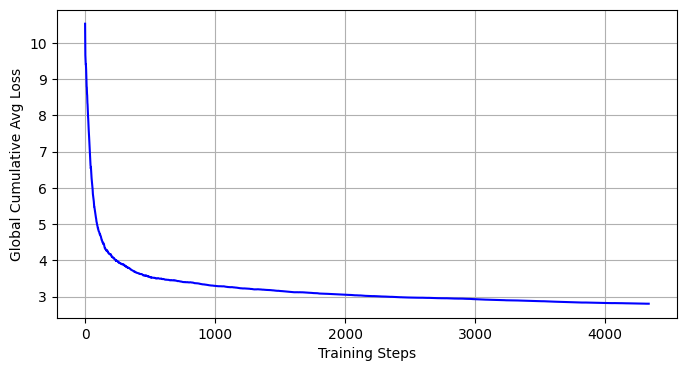

In [20]:
# Sanity check: decreasing trend of global average training loss
plt.figure(figsize=(8,4))
plt.plot(global_train_losses, label="Global Avg Train Loss", color='blue')
plt.xlabel("Training Steps")
plt.ylabel("Global Cumulative Avg Loss")
plt.grid(True)
plt.show()

## Inference: Autoregressive Text Generation

Now that we have a trained model, we can use it for prediction. The model generates text **one token at a time** — it predicts the next token, appends it to the input, and repeats. This is the same next-token prediction learned during training (Q6), just used in a loop without computing loss.

In [21]:
def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=1.0, strategy="greedy", device=DEVICE):
    # Switch model to evaluation mode — disables dropout so outputs are deterministic
    model.eval()

    # Tokenize the prompt string into token IDs, e.g. "Once upon" → [7454, 2402]
    input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(device)

    # Generate tokens one at a time in an autoregressive loop
    for _ in range(max_new_tokens):
        # Create attention mask: all 1s because we have no padding during generation
        attention_mask = torch.ones_like(input_ids)

        # No gradient tracking needed — we're not training, just predicting
        with torch.no_grad():
            # Forward pass: input_ids → embeddings → transformer layers → hidden states
            output = model(input_ids, attention_mask)
            # Get hidden states for ALL token positions: shape (1, seq_len, hidden_size)
            hidden_states = output['last_hidden_state']
            # Convert hidden states to vocabulary logits using weight-tied projection
            # hidden_states @ word_embedding.weight.T → shape (1, seq_len, vocab_size)
            logits = model.hidden_state_to_token(hidden_states)

        # We only care about the LAST position's prediction — that's the next token
        # Shape: (1, vocab_size) — a probability score for every token in the vocabulary
        next_token_logits = logits[:, -1, :]

        if strategy == "greedy":
            # Greedy: always pick the token with the highest logit (most likely next token)
            next_token = next_token_logits.argmax(dim=-1, keepdim=True)
        elif strategy == "sample":
            # Sampling: divide logits by temperature before softmax
            # temperature < 1.0 → sharper distribution (more confident, less random)
            # temperature > 1.0 → flatter distribution (more creative, more random)
            probs = F.softmax(next_token_logits / temperature, dim=-1)
            # Randomly sample one token from the probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

        # Stop generating if the model predicts the end-of-sequence token
        if next_token.item() == tokenizer.eos_token_id:
            break

        # Append the predicted token to the input sequence for the next iteration
        # e.g. [7454, 2402] → [7454, 2402, 257] — the sequence grows by 1 each loop
        input_ids = torch.cat([input_ids, next_token], dim=1)

        # Safety check: don't exceed the model's max sequence length (position embedding limit)
        if input_ids.shape[1] >= MAX_SEQ_LEN:
            break

    # Decode all token IDs back to a human-readable string
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

In [24]:
# Test generation with different strategies and prompts
prompt = "CNN reported that"

# Greedy decoding — deterministic, always picks the most likely next token
print("=== Greedy ===")
print(generate(toy_gpt2_model, tokenizer, prompt, max_new_tokens=50, strategy="greedy"))

# Sampling with low temperature — more focused/confident output
print("\n=== Sampling (temp=0.8) ===")
print(generate(toy_gpt2_model, tokenizer, prompt, max_new_tokens=50, strategy="sample", temperature=0.8))

# Sampling with high temperature — more random/creative output
print("\n=== Sampling (temp=1.2) ===")
print(generate(toy_gpt2_model, tokenizer, prompt, max_new_tokens=50, strategy="sample", temperature=1.2))

=== Greedy ===
CNN reported that the US of the US of the US of the US is a number of the same of the same of the same of the same of the same of the same of the same of the same of the same of the same of the same of the same

=== Sampling (temp=0.8) ===
CNN reported that language, the latest to start of the global Americans. The S explodes and Krue with the island, Lester, a little newfound design and Reich (2) and Krueger (2010, protesters on the same list of the topics in the minimum

=== Sampling (temp=1.2) ===
CNN reported that helmets, like a used into facial culture. Act corps Rigman vulnerable marijuana Chongoped updates Mattzo Bleets Duke later to play all I would addmaker scored at that would’mgros number of driving and cheer hidden in returning better.
